# Oráculo: ruido, resta de ruido y umbrales de censura

Oráculo de `docs/algorithms/ruido-y-umbrales.md`, independiente de cualquier
crate Rust (todavía no existe implementación — éste es el primer paso del
método de `docs/algorithms/roadmap.md` §"Método de estudio" para este
algoritmo).

Cubre las dos mitades del problema descritas en la página:

1. **Estimación del suelo de ruido** por el método objetivo de Hildebrand &
   Sekhon (1974): a partir del periodograma de una única ráfaga de `M` pulsos,
   separa las líneas espectrales de ruido sin saber a priori dónde está la
   señal.
2. **Resta y censura**: `S = R(0) - N` recortado a cero, y la tasa de falsos
   positivos de `sig_threshold` sobre celdas puramente de ruido.

No cubre el estimador por radial de Ivić, Curtis & Torres (2013) — la página
lo señala como método de operación continua, no como el objetivo de
verdad-terreno de este oráculo.

El generador de I/Q se reimplementa aquí desde cero (Zrnić 1975, ver
`docs/algorithms/simulador-iq.md`) en vez de importarse del oráculo del
simulador, para que este notebook sea autocontenido.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260901)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

## Generador de I/Q (Zrnić 1975)

Espectro Doppler gaussiano discreto sobre la rejilla de bins de la FFT, con
réplicas envueltas para cubrir el caso `sigma_v` cerca de la velocidad de
Nyquist, conformado de ruido blanco complejo, IFFT sin normalizar, y ruido
térmico aditivo — igual formulación que el oráculo del simulador de I/Q.

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    """Densidad espectral discreta S[k] en orden nativo de bin de la FFT,
    normalizada para que sum(S) == power_s."""
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0

    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    """CN(0, variance): partes real e imaginaria independientes N(0, variance/2)."""
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    """Serie temporal de una celda de rango, un canal, con ruido térmico
    aditivo. `noise_floor` es la potencia total N de la nota de la página
    (E[|ruido[n]|^2] == noise_floor), no una densidad por bin."""
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y

## Periodograma y comprobación de Parseval

`R(0) = E[|y[n]|^2] = potencia_s + noise_floor` es la cantidad que un
estimador real mide directamente en el dominio temporal. El periodograma
`P[k] = |FFT(y)[k]|^2 / M^2` reparte esa misma potencia total entre bins —es
una identidad de Parseval, no una aproximación— y es lo que alimenta
Hildebrand & Sekhon.

In [3]:
def periodogram(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


_check_y = generate_cell(1.0, 5.0, 1.5, 0.10, 1.0e-3, 128, 0.3, rng)
_lhs = np.mean(np.abs(_check_y) ** 2)
_rhs = periodogram(_check_y).sum()
print(f"Parseval: media(|y|^2)={_lhs:.6f}  suma(periodograma)={_rhs:.6f}  diff={abs(_lhs - _rhs):.2e}")
assert abs(_lhs - _rhs) < 1e-9, "el periodograma no reparte la misma potencia total que la serie temporal"

Parseval: media(|y|^2)=1.547725  suma(periodograma)=1.547725  diff=4.44e-16


## Hildebrand & Sekhon (1974)

Para ruido blanco gaussiano complejo, cada bin del periodograma es exponencial
(chi-cuadrado, 2 grados de libertad) e independiente de los demás —el DFT de
un vector gaussiano complejo i.i.d. es a su vez gaussiano complejo i.i.d.,
exactamente, sin importar `M`.

La formulación de la propia Hildebrand & Sekhon (1974), ecuación 9, ordena el
periodograma ascendente y va incluyendo bins desde el más pequeño mientras las
sumas acumuladas `sum1 = Σp`, `sum2 = Σp²` de los primeros `i` bins sigan
pasando la prueba `i·sum2 < sum1²·(1 + 1/navg)` —consistente con ruido blanco,
donde `navg` es el número de espectros independientes promediados antes de
aplicar el método (`navg=1` para un periodograma de una sola ráfaga, que es el
caso de este oráculo). Donde la prueba falla, ese bin y los siguientes ya no
son ruido puro. Fórmula verificada contra la implementación pública
`pyart.util.hildebrand_sekhon.estimate_noise_hs74` — una de las
"implementaciones abiertas" que la propia página cita como oráculo directo.

In [4]:
def hildebrand_sekhon(p, navg=1):
    """p: periodograma de una única ráfaga (M valores). Devuelve la media de
    ruido por bin estimada (ecuación 9 de Hildebrand & Sekhon 1974)."""
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    """Estima N (potencia total de ruido, no por bin) de una ráfaga."""
    m = len(y)
    return hildebrand_sekhon(periodogram(y)) * m

## Prueba 1 — celdas puramente de ruido

Sin señal, todos los bins son ruido. Con `navg=1` (periodograma de una sola
ráfaga, sin promediar) Hildebrand & Sekhon tiene un sesgo negativo pequeño y
conocido: la prueba trunca por azar la cola alta de la distribución
exponencial de vez en cuando incluso sin señal presente, y eso baja la media
del subconjunto aceptado. Se comprueba que la estimación queda dentro de ese
sesgo esperado, no que sea exactamente insesgada.

In [5]:
NOISE_FLOOR = 0.3
M = 256
N_TRIALS_PURE = 4000
BIAS_TOLERANCE_DB = 1.0  # sesgo conocido de HS74 con navg=1 es de ~0.4 dB

pure_noise_estimates = np.array([
    noise_floor_estimate(generate_cell(0.0, 0.0, 1.0, 0.10, 1.0e-3, M, NOISE_FLOOR, rng))
    for _ in range(N_TRIALS_PURE)
])

mean_est = pure_noise_estimates.mean()
bias_db = 10.0 * np.log10(mean_est / NOISE_FLOOR)
print(f"N inyectado={NOISE_FLOOR}  N estimado={mean_est:.4f}  sesgo={bias_db:.3f} dB")

checks = []
checks.append((f"HS74 sobre ruido puro recupera N inyectado (< {BIAS_TOLERANCE_DB} dB)",
               abs(bias_db) < BIAS_TOLERANCE_DB))

N inyectado=0.3  N estimado=0.2756  sesgo=-0.369 dB


## Prueba 2 — sesgo de reflectividad frente a SNR

Barrido de SNR con `noise_floor` fijo. Por cada punto: `R(0)` se estima como
la potencia media temporal de la ráfaga, `N` por Hildebrand & Sekhon, y
`S = max(R(0) - N, 0)`. El criterio de la página es sesgo despreciable hasta
SNR ≈ 0 dB, con sesgo acotado y documentado por debajo — ahí domina la
censura (`S_hat == 0`), no el sesgo del estimador de ruido.

SNR= -10.0 dB  sesgo= -15.513 dB  censuradas=331/2000 (16.6%)


SNR=  -5.0 dB  sesgo=  -1.747 dB  censuradas=7/2000 (0.4%)


SNR=   0.0 dB  sesgo=  -0.395 dB  censuradas=0/2000 (0.0%)


SNR=   5.0 dB  sesgo=  -0.132 dB  censuradas=0/2000 (0.0%)


SNR=  10.0 dB  sesgo=  -0.092 dB  censuradas=0/2000 (0.0%)


SNR=  15.0 dB  sesgo=  -0.069 dB  censuradas=0/2000 (0.0%)


SNR=  20.0 dB  sesgo=  -0.082 dB  censuradas=0/2000 (0.0%)


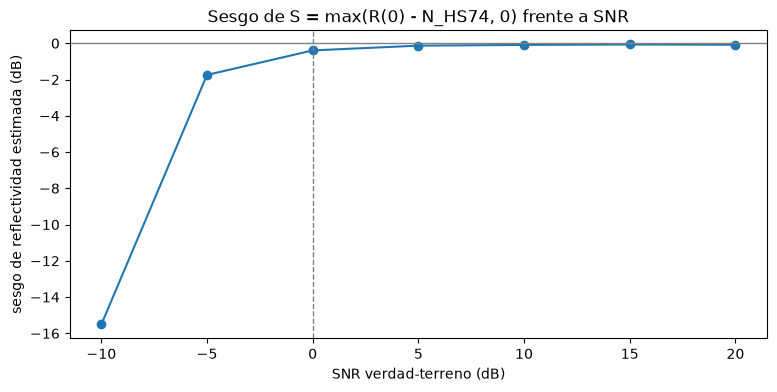

In [6]:
MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S = 5.0, 1.5, 0.10, 1.0e-3
SNR_DB_GRID = np.array([-10.0, -5.0, 0.0, 5.0, 10.0, 15.0, 20.0])
N_TRIALS_SNR = 2000

bias_db_snr = np.zeros_like(SNR_DB_GRID)
censored_frac = np.zeros_like(SNR_DB_GRID)

for i, snr_db in enumerate(SNR_DB_GRID):
    power_s = NOISE_FLOOR * 10.0 ** (snr_db / 10.0)
    errors = []
    n_censored = 0
    for _ in range(N_TRIALS_SNR):
        y = generate_cell(power_s, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)
        r0_hat = np.mean(np.abs(y) ** 2)
        n_hat = noise_floor_estimate(y)
        s_hat = max(r0_hat - n_hat, 0.0)
        # celdas censuradas (S_hat == 0) se excluyen del sesgo en dB, igual
        # que en el receptor real: no hay logaritmo de una celda censurada.
        if s_hat > 0.0:
            errors.append(10.0 * np.log10(s_hat / power_s))
        else:
            n_censored += 1
    errors = np.array(errors)
    bias_db_snr[i] = errors.mean()
    censored_frac[i] = n_censored / N_TRIALS_SNR
    print(f"SNR={snr_db:6.1f} dB  sesgo={bias_db_snr[i]:8.3f} dB  "
          f"censuradas={n_censored}/{N_TRIALS_SNR} ({censored_frac[i]:.1%})")

fig, ax = plt.subplots()
ax.plot(SNR_DB_GRID, bias_db_snr, marker="o")
ax.axhline(0.0, color="gray", linewidth=1)
ax.axvline(0.0, color="gray", linewidth=1, linestyle="--")
ax.set_xlabel("SNR verdad-terreno (dB)")
ax.set_ylabel("sesgo de reflectividad estimada (dB)")
ax.set_title("Sesgo de S = max(R(0) - N_HS74, 0) frente a SNR")
plt.show()

for snr_db, bias in zip(SNR_DB_GRID, bias_db_snr):
    if snr_db >= 0.0:
        checks.append((f"sesgo despreciable a SNR={snr_db:.0f} dB (< 1 dB)", abs(bias) < 1.0))
    else:
        # por debajo de 0 dB el criterio es "acotado y documentado", no
        # "despreciable" — el número queda impreso arriba; este assert sólo
        # atrapa una regresión grosera del estimador, no exige insesgadez.
        checks.append((f"sesgo acotado a SNR={snr_db:.0f} dB (< 20 dB, documentado)", abs(bias) < 20.0))

## Prueba 3 — tasa de falsos positivos de `sig_threshold`

Sobre celdas puramente de ruido, ¿con qué frecuencia `S_hat/N` supera un
`sig_threshold` declarado aunque no haya señal? La página exige que quede por
debajo de un valor declarado para la configuración; aquí se declara 5% para
`sig_threshold = 3 dB`.

sig_threshold=3.0 dB  falsos positivos=0.0000 (N=4000, límite declarado=0.05)


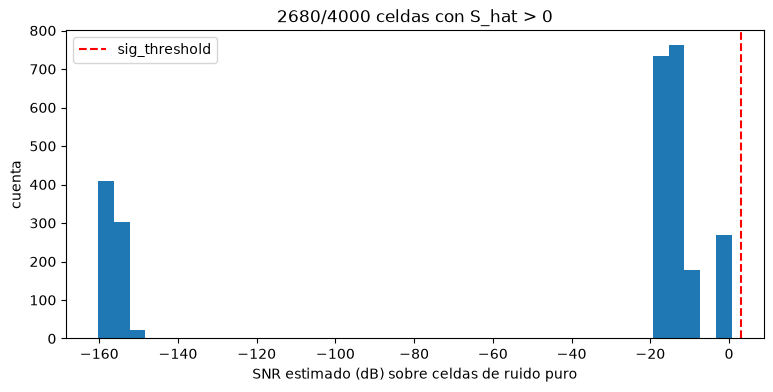

In [7]:
SIG_THRESHOLD_DB = 3.0
FP_BOUND = 0.05

snr_hat_db = np.full(N_TRIALS_PURE, -np.inf)
for t in range(N_TRIALS_PURE):
    y = generate_cell(0.0, 0.0, 1.0, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)
    r0_hat = np.mean(np.abs(y) ** 2)
    n_hat = noise_floor_estimate(y)
    s_hat = max(r0_hat - n_hat, 0.0)
    if s_hat > 0.0:
        snr_hat_db[t] = 10.0 * np.log10(s_hat / NOISE_FLOOR)

false_positive_rate = np.mean(snr_hat_db > SIG_THRESHOLD_DB)
print(f"sig_threshold={SIG_THRESHOLD_DB} dB  falsos positivos={false_positive_rate:.4f} "
      f"(N={N_TRIALS_PURE}, límite declarado={FP_BOUND})")

checks.append((f"tasa de falsos positivos < {FP_BOUND:.0%} a sig_threshold={SIG_THRESHOLD_DB} dB",
               false_positive_rate < FP_BOUND))

fig, ax = plt.subplots()
finite = snr_hat_db[np.isfinite(snr_hat_db)]
ax.hist(finite, bins=40)
ax.axvline(SIG_THRESHOLD_DB, color="red", linestyle="--", label="sig_threshold")
ax.set_xlabel("SNR estimado (dB) sobre celdas de ruido puro")
ax.set_ylabel("cuenta")
ax.set_title(f"{len(finite)}/{N_TRIALS_PURE} celdas con S_hat > 0")
ax.legend()
plt.show()

In [8]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de ruido/umbrales no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] HS74 sobre ruido puro recupera N inyectado (< 1.0 dB)
[OK] sesgo acotado a SNR=-10 dB (< 20 dB, documentado)
[OK] sesgo acotado a SNR=-5 dB (< 20 dB, documentado)
[OK] sesgo despreciable a SNR=0 dB (< 1 dB)
[OK] sesgo despreciable a SNR=5 dB (< 1 dB)
[OK] sesgo despreciable a SNR=10 dB (< 1 dB)
[OK] sesgo despreciable a SNR=15 dB (< 1 dB)
[OK] sesgo despreciable a SNR=20 dB (< 1 dB)
[OK] tasa de falsos positivos < 5% a sig_threshold=3.0 dB

Todas las comprobaciones dentro de tolerancia.
